Base: Leads Reales
Variable independiente (X):Abiertos, Variable dependiente (Y): Ventas

In [1]:
# 1. Cargar y poner bien la cabecera
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression

df = pd.read_csv('Leads_Reales.csv', skiprows=2, encoding='utf-8-sig')
df.columns = df.columns.str.strip()
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]
df.head()

,Año,Mes,Total,Ilocalizable,No Contesta,D. Incorrectos,Duplicados,Efectivos,Abiertos,Ventas,Conversion,Efectividad de Leads
0,2024.0,Enero,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,Febrero,543,108,33,0,1,389,1,12,3.1%,72%
2,NaN,Marzo,178,37,13,0,0,128,1,7,5.5%,72%
3,NaN,Abril,416,79,46,3,0,288,1,8,2.8%,69%
4,NaN,Mayo,422,33,100,17,0,274,5,13,4.7%,65%


In [2]:
# 2. Depurar nulos (rellenar Año, quitar filas basura)
# rellenar Año hacia abajo ANTES de tirar filas (si no, se pierde el 2024)
df['Año'] = df['Año'].ffill()

meses_validos = ['Enero','Febrero','Marzo','Abril','Mayo','Junio','Julio',
                  'Agosto','Septiembre','Octubre','Noviembre','Diciembre']
df['Mes'] = df['Mes'].astype(str).str.strip()

# esto tira todo el bloque de resumen/formulas que trae el archivo al final
df = df[df['Mes'].isin(meses_validos)].reset_index(drop=True)

# tirar filas sin ningun dato cargado (ej. Enero 2024 viene vacio)
cols_dato = ['Total','Ilocalizable','No Contesta','D. Incorrectos',
             'Duplicados','Efectivos','Abiertos','Ventas']
df = df.dropna(subset=cols_dato, how='all').reset_index(drop=True)

df.shape  # debe darte (28, 12)

(28, 12)

In [3]:
# 3. Año y Mes a numérico
mapa_meses = {m: i+1 for i, m in enumerate(meses_validos)}
df['Mes'] = df['Mes'].map(mapa_meses).astype('Int64')
df['Año'] = pd.to_numeric(df['Año'], errors='coerce').astype('Int64')
df[['Año','Mes']].head()

,Año,Mes
0,2024,2
1,2024,3
2,2024,4
3,2024,5
4,2024,6


In [4]:
# 4. Resto de variables a numérico
cols_numericas = ['Total','Ilocalizable','No Contesta','D. Incorrectos',
                   'Duplicados','Efectivos','Abiertos','Ventas']
for c in cols_numericas:
    df[c] = df[c].astype(str).str.replace(',', '', regex=False).str.strip()
    df[c] = pd.to_numeric(df[c], errors='coerce')
df[cols_numericas].dtypes

Total             int64
Ilocalizable      int64
No Contesta       int64
D. Incorrectos    int64
Duplicados        int64
Efectivos         int64
Abiertos          int64
Ventas            int64
dtype: object

In [5]:
# 5. Conversión y Efectividad de Leads: quitar % y a numérico
for c in ['Conversion', 'Efectividad de Leads']:
    df[c] = df[c].astype(str).str.replace('%', '', regex=False).str.strip()
    df[c] = pd.to_numeric(df[c], errors='coerce')
df[['Conversion', 'Efectividad de Leads']].head()

,Conversion,Efectividad de Leads
0,3.1,72
1,5.5,72
2,2.8,69
3,4.7,65
4,1.0,64


In [6]:
# 6. Outliers con IQR (capado)
cols_para_outliers = ['Total','Ilocalizable','No Contesta','D. Incorrectos',
                       'Duplicados','Efectivos','Abiertos','Ventas',
                       'Conversion','Efectividad de Leads']
for c in cols_para_outliers:
    Q1, Q3 = df[c].quantile(0.25), df[c].quantile(0.75)
    IQR = Q3 - Q1
    df[c] = df[c].clip(lower=Q1-1.5*IQR, upper=Q3+1.5*IQR)

df.to_csv('Leads_Reales_Depurado.csv', index=False)
df.describe()

,Año,Mes,Total,Ilocalizable,No Contesta,D. Incorrectos,Duplicados,Efectivos,Abiertos,Ventas,Conversion,Efectividad de Leads
count,28.0,28.0,28.000000,28.000000,28.000000,28.000000,28.000000,28.000000,28.000000,28.000000,28.000000,28.000000
mean,2024.785714,6.071429,1126.191964,123.678571,205.285714,19.107143,33.089286,666.500000,250.107143,26.964286,4.142857,61.642857
std,0.738223,3.452627,414.499022,99.463628,143.242764,19.345474,29.891797,191.859999,236.059839,11.083796,1.249720,11.907714
min,2024.0,1.0,271.375000,5.000000,13.000000,0.000000,0.000000,303.000000,1.000000,6.000000,1.000000,39.000000
25%,2024.0,3.0,946.750000,44.250000,103.000000,3.000000,12.000000,564.000000,37.000000,19.250000,3.275000,52.750000
50%,2025.0,5.5,1170.500000,110.000000,185.500000,13.000000,27.000000,704.500000,200.500000,30.000000,4.050000,64.000000
75%,2025.0,9.0,1397.000000,154.250000,278.000000,31.750000,53.000000,738.000000,368.000000,36.250000,5.275000,70.000000
max,2026.0,12.0,1973.000000,319.250000,540.500000,62.000000,114.500000,999.000000,823.000000,41.000000,5.900000,83.000000


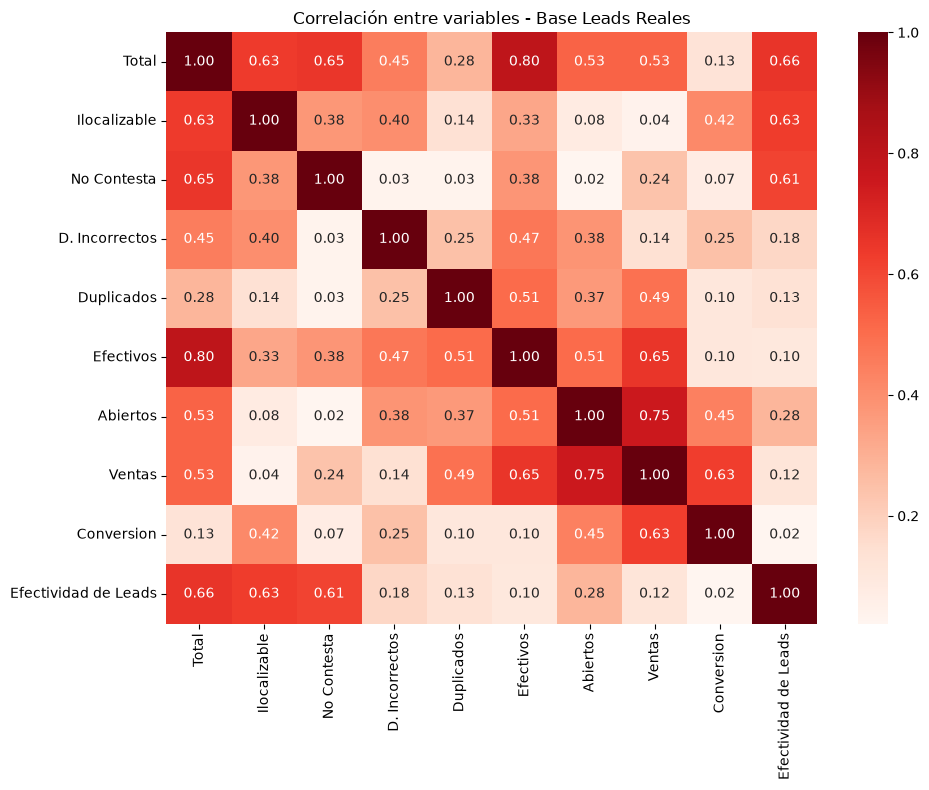

In [7]:
# 7. Correlación entre todas las variables de Leads (punto 6)
cols_leads = ['Total','Ilocalizable','No Contesta','D. Incorrectos','Duplicados',
              'Efectivos','Abiertos','Ventas','Conversion','Efectividad de Leads']

Corr_Factors = df[cols_leads].corr()
Corr_Factors1 = abs(Corr_Factors)

plt.figure(figsize=(10,8))
sns.heatmap(Corr_Factors1, cmap='Reds', annot=True, fmt=".2f")
plt.title('Correlación entre variables - Base Leads Reales')
plt.tight_layout()

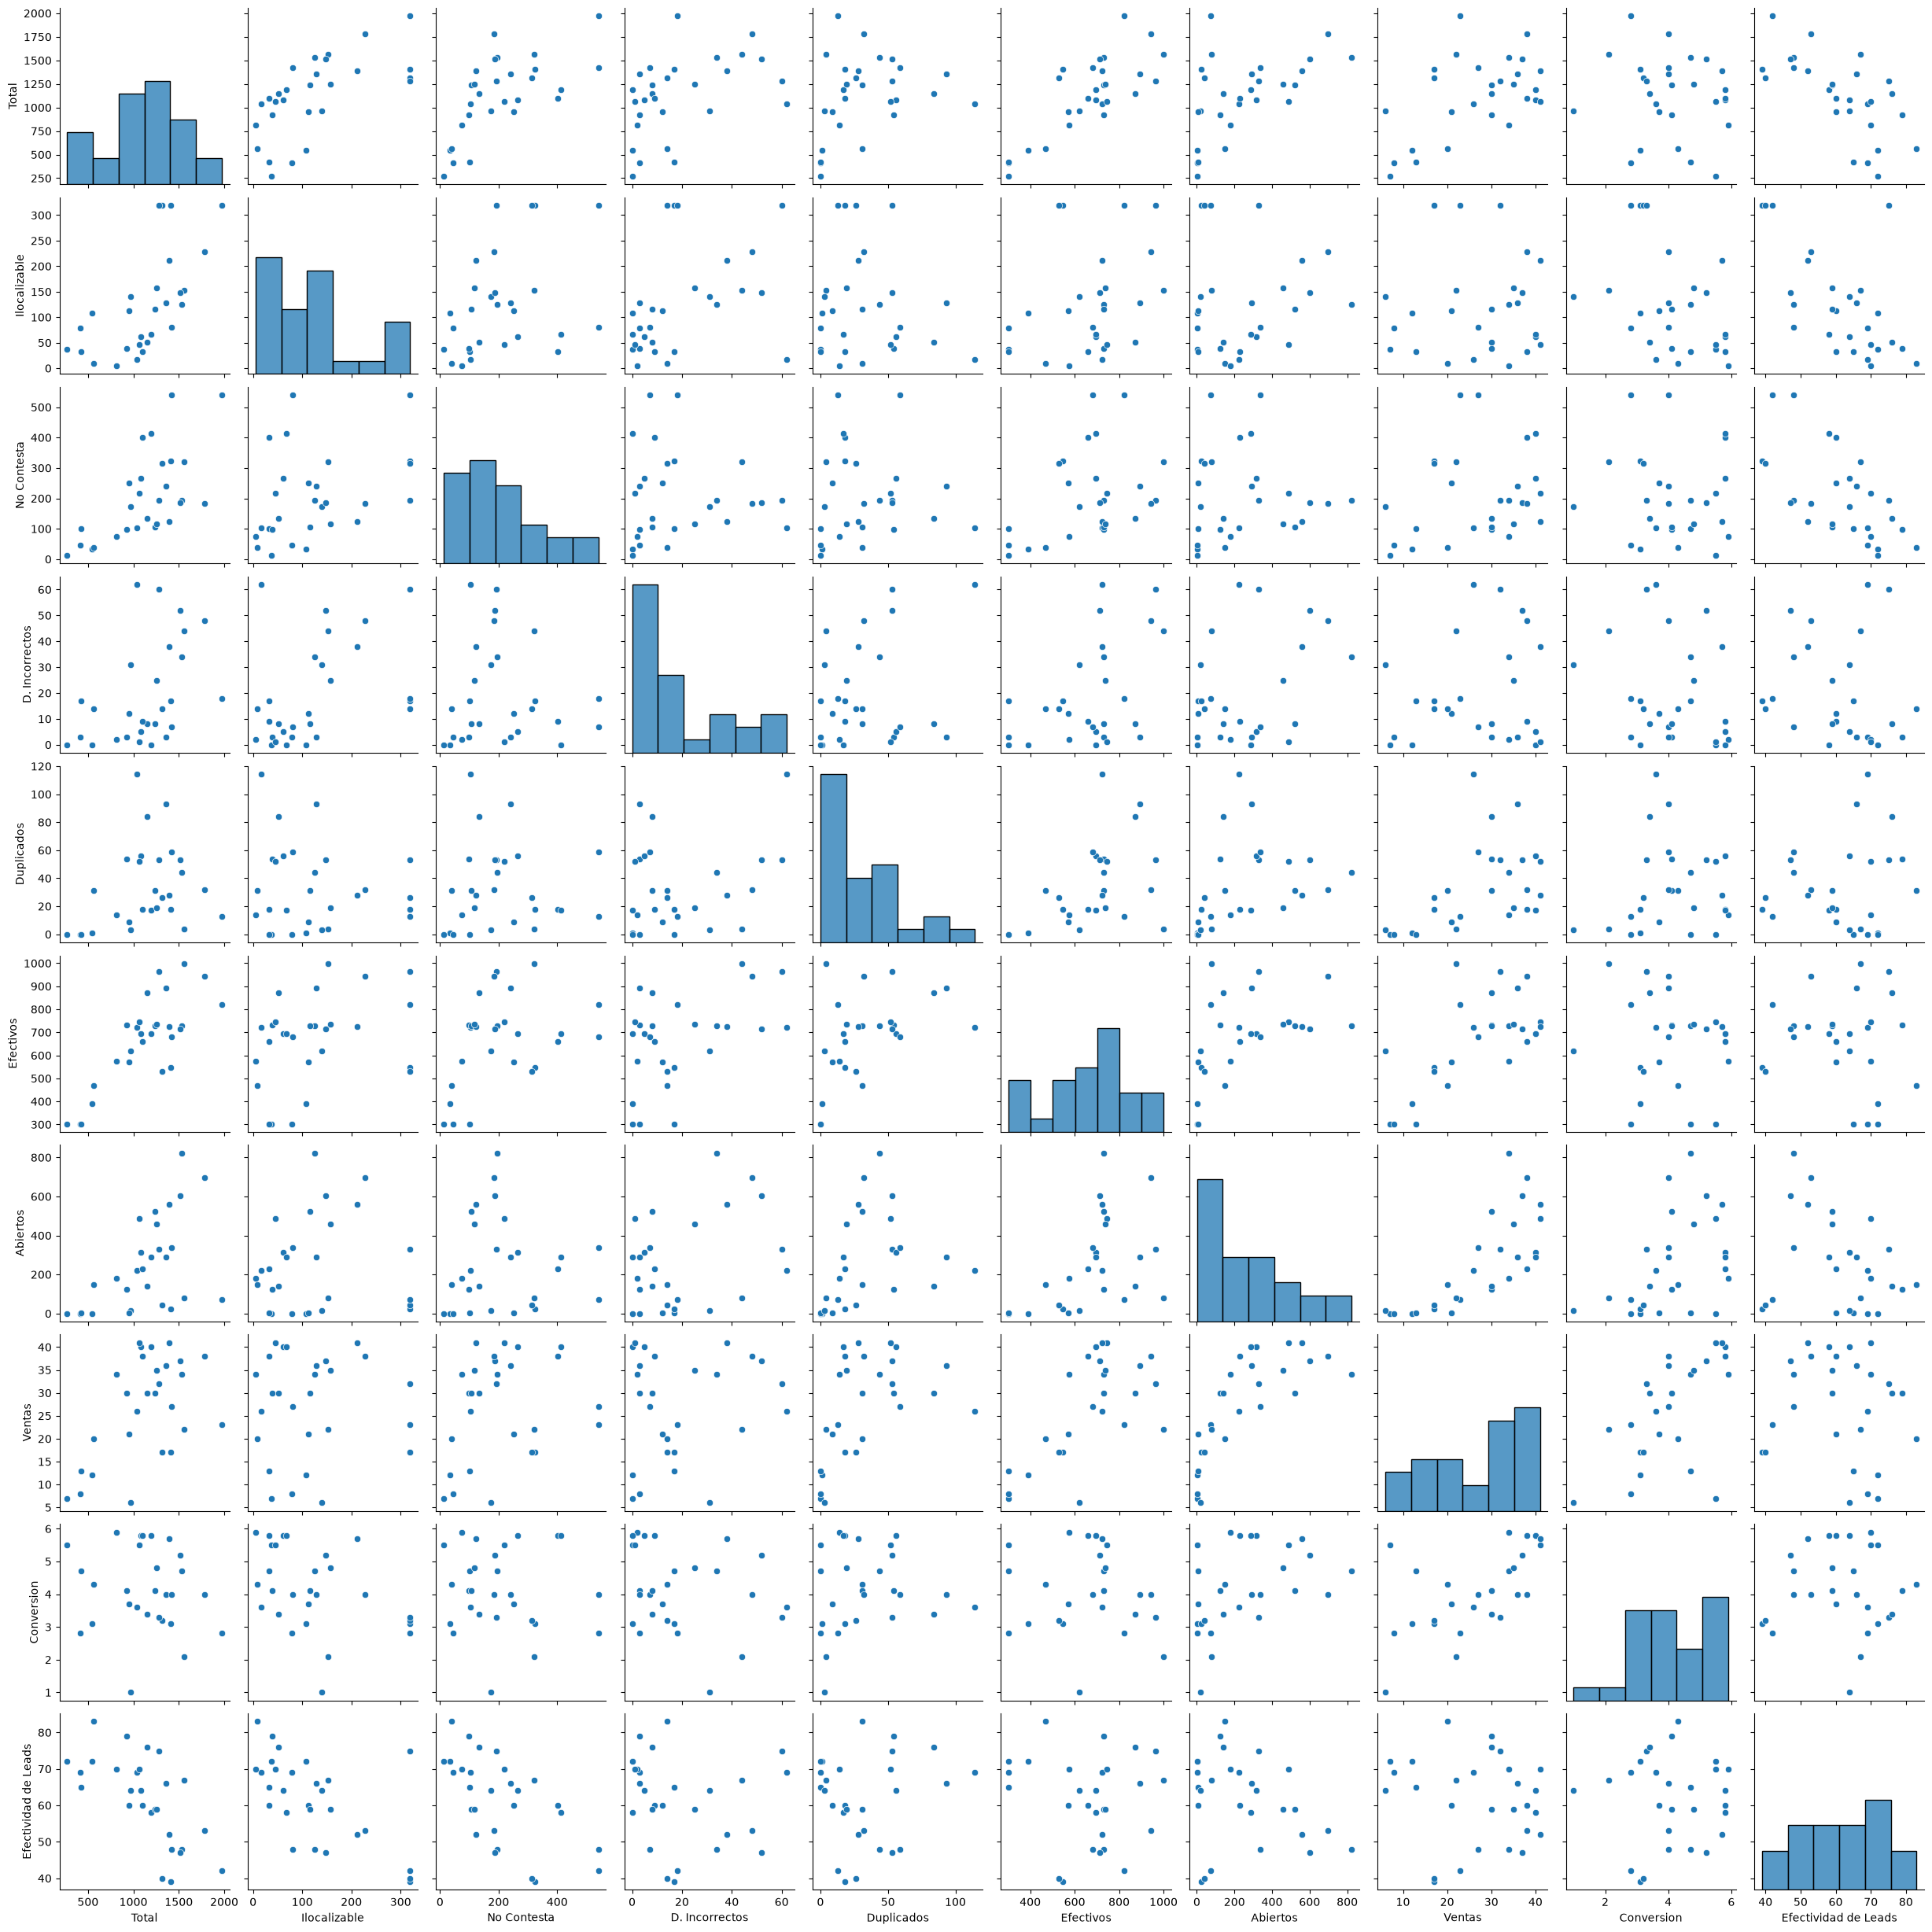

In [8]:
# 8. Dispersión entre todas las variables
sns.pairplot(df[cols_leads])

In [9]:
# 9. Modelo de regresión: X = Abiertos, Y = Ventas
Vars_Indep = df[['Abiertos']]
Var_Dep = df['Ventas']

model_leads = LinearRegression()
model_leads.fit(X=Vars_Indep, y=Var_Dep)
model_leads.__dict__

{'fit_intercept': True,
 'copy_X': True,
 'tol': 1e-06,
 'n_jobs': None,
 'positive': False,
 'feature_names_in_': array(['Abiertos'], dtype=object),
 'n_features_in_': 1,
 'coef_': array([0.03533478]),
 'rank_': np.int64(1),
 'singular_': array([1226.60290175]),
 'intercept_': np.float64(18.126805081456116)}

R²: 0.5663330934367705


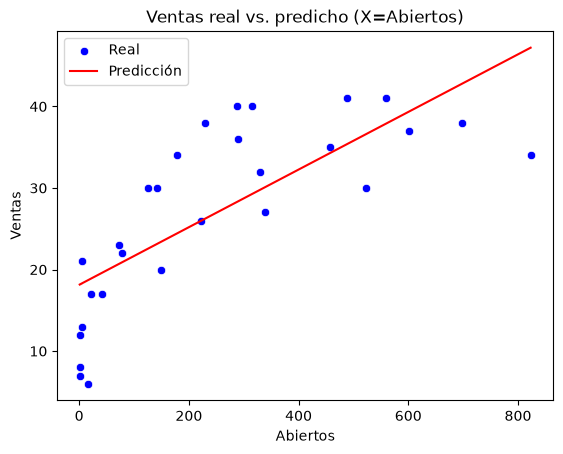

In [10]:
# 10. R², predicciones y gráfica
r2_leads = model_leads.score(Vars_Indep, Var_Dep)
print("R²:", r2_leads)

y_pred = model_leads.predict(X=Vars_Indep)
df['Predicciones_Ventas'] = y_pred

sns.scatterplot(x='Abiertos', y='Ventas', color="blue", data=df, label='Real')
sns.lineplot(x='Abiertos', y='Predicciones_Ventas', color="red", data=df, label='Predicción')
plt.title('Ventas real vs. predicho (X=Abiertos)')
plt.legend()

In [11]:
# 11. Coeficiente de correlación
coef_correl_leads = np.sqrt(r2_leads)
coef_correl_leads

np.float64(0.7525510570298672)